In [22]:
def get_year_months():
    year_months = []
    for year in range(2015, 2024+1):
        for month in range (1, 12+1):
            year_months.append(f'{year}/{month:02d}')
    return year_months

import requests 
urlPrefix = "http://openapi.seoul.go.kr:8088/"
authKey = "497a75577562616e3734697378526d"
endpoint = "/json/energyUseDataSummaryInfo/1/5/"
params = {
    'KEY' : authKey,
    'TYPE' : 'json',
    'SERVICE' : 'energyUseDataSummaryInfo'
}


dataResult = []
for appendYearMonth in get_year_months():
    fullPath = urlPrefix + authKey + endpoint + appendYearMonth
    response = requests.get(fullPath, params=params)
    if response.status_code == 200:
        tmp = appendYearMonth.split("/")
        print(tmp[0] + "년" + tmp[1]+"월 호출 " + response.json()["energyUseDataSummaryInfo"]["RESULT"]["MESSAGE"])
        dataResult.extend(response.json()["energyUseDataSummaryInfo"]["row"])
    else:
        print("api call fail")
        break
print(dataResult)

2015년01월 호출 정상 처리되었습니다
2015년02월 호출 정상 처리되었습니다
2015년03월 호출 정상 처리되었습니다
2015년04월 호출 정상 처리되었습니다
2015년05월 호출 정상 처리되었습니다
2015년06월 호출 정상 처리되었습니다
2015년07월 호출 정상 처리되었습니다
2015년08월 호출 정상 처리되었습니다
2015년09월 호출 정상 처리되었습니다
2015년10월 호출 정상 처리되었습니다
2015년11월 호출 정상 처리되었습니다
2015년12월 호출 정상 처리되었습니다
2016년01월 호출 정상 처리되었습니다
2016년02월 호출 정상 처리되었습니다
2016년03월 호출 정상 처리되었습니다
2016년04월 호출 정상 처리되었습니다
2016년05월 호출 정상 처리되었습니다
2016년06월 호출 정상 처리되었습니다
2016년07월 호출 정상 처리되었습니다
2016년08월 호출 정상 처리되었습니다
2016년09월 호출 정상 처리되었습니다
2016년10월 호출 정상 처리되었습니다
2016년11월 호출 정상 처리되었습니다
2016년12월 호출 정상 처리되었습니다
2017년01월 호출 정상 처리되었습니다
2017년02월 호출 정상 처리되었습니다
2017년03월 호출 정상 처리되었습니다
2017년04월 호출 정상 처리되었습니다
2017년05월 호출 정상 처리되었습니다
2017년06월 호출 정상 처리되었습니다
2017년07월 호출 정상 처리되었습니다
2017년08월 호출 정상 처리되었습니다
2017년09월 호출 정상 처리되었습니다
2017년10월 호출 정상 처리되었습니다
2017년11월 호출 정상 처리되었습니다
2017년12월 호출 정상 처리되었습니다
2018년01월 호출 정상 처리되었습니다
2018년02월 호출 정상 처리되었습니다
2018년03월 호출 정상 처리되었습니다
2018년04월 호출 정상 처리되었습니다
2018년05월 호출 정상 처리되었습니다
2018년06월 호출 정상 처리되었습니다
2018년07월 호출 정상 처리되었습니다
2018년08월 호출

KeyboardInterrupt: 

In [ ]:
import pandas as pd

# 전체 내용중 필요한 정보만 추출하여 copy
df = pd.DataFrame(dataResult)
df_mapped = df[["YEAR", "MON", "MM_TYPE", "EUS", "GUS", "WUS", "HUS"]].copy()

# 한글 컬럼명 매핑
df_mapped = df_mapped.rename(columns={
    "YEAR": "년도",
    "MON": "월",
    "MM_TYPE": "회원타입",
    "EUS": "현년 전기사용량",
    "GUS": "현년 가스사용량",
    "WUS": "현년 수도사용량",
    "HUS": "현년 지역난방 사용량"
})

df_mapped

,년도,월,회원타입,현년 전기사용량,현년 가스사용량,현년 수도사용량,현년 지역난방 사용량
0,2015,01,개인,193784708,59133720,12819757.886,22740838.937
1,2015,01,학교,134955565,9107197,2075819.2,0
2,2015,01,종교단체,372270,53331,5945,0
3,2015,01,소상공인,10249618,536119,147273,0
4,2015,01,공동주택관리소,327102096,22834274,12844807.5,0
...,...,...,...,...,...,...,...
595,2024,12,공동주택관리소,548480228,8221238,20262147.7,0
596,2024,12,기업,633735769,30096486,4448777.4,0
597,2024,12,개인,134828126,42103424,7326853.6,1513199.277
598,2024,12,공공기관,152992881,3814815,896842,0


In [ ]:
print("==== 추출한 데이터 기본 통계량 ====")
print(df_mapped.describe())
print("==== 추출한 데이터 기본 정보 ====")
print(df_mapped.head())

==== 추출한 데이터 기본 통계량 ====
          년도    월 회원타입   현년 전기사용량  현년 가스사용량 현년 수도사용량 현년 지역난방 사용량
count    600  600  600        600       600      600         600
unique    10   12    7        600       600      598         213
top     2015   01   학교  193784708  59133720        0           0
freq      60   50   93          1         1        3         378
==== 추출한 데이터 기본 정보 ====
     년도   월     회원타입   현년 전기사용량  현년 가스사용량      현년 수도사용량   현년 지역난방 사용량
0  2015  01       개인  193784708  59133720  12819757.886  22740838.937
1  2015  01       학교  134955565   9107197     2075819.2             0
2  2015  01     종교단체     372270     53331          5945             0
3  2015  01     소상공인   10249618    536119        147273             0
4  2015  01  공동주택관리소  327102096  22834274    12844807.5             0


In [ ]:
import numpy as np
df_mapped["월"] = df_mapped["월"].astype(int)

# 계절 컬럼 추가
df_mapped["계절"] = df_mapped["월"].map(lambda x: 
    "봄" if 3 <= x <= 5 else
    "여름" if 6 <= x <= 8 else
    "가을" if 9 <= x <= 11 else
    "겨울" if x in [12, 1, 2] else ""
)
season_col = df_mapped.pop("계절")  
df_mapped.insert(1, "계절", season_col)
df_mapped.columns.tolist()


['년도', '계절', '월', '회원타입', '현년 전기사용량', '현년 가스사용량', '현년 수도사용량', '현년 지역난방 사용량']

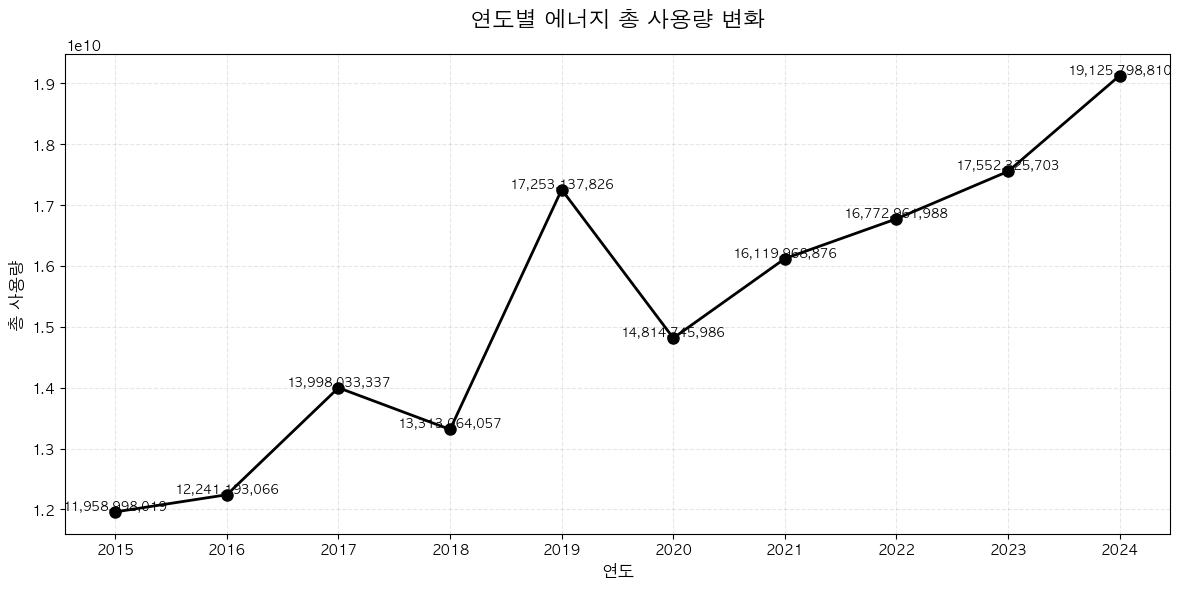

In [ ]:
import matplotlib.pyplot as plt

# 1. 한글 폰트 설정 (한글 깨짐 방지)
plt.rcParams['font.family'] = 'AppleGothic'  # Mac
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

# 데이터를 숫자형으로 변환
df_mapped['현년 전기사용량'] = pd.to_numeric(df_mapped['현년 전기사용량'], errors='coerce')
df_mapped['현년 가스사용량'] = pd.to_numeric(df_mapped['현년 가스사용량'], errors='coerce')
df_mapped['현년 수도사용량'] = pd.to_numeric(df_mapped['현년 수도사용량'], errors='coerce')
df_mapped['현년 지역난방 사용량'] = pd.to_numeric(df_mapped['현년 지역난방 사용량'], errors='coerce')

# 2. 연도별 에너지 총 사용량 계산
df_energy = df_mapped.groupby('년도').agg({
    '현년 전기사용량': 'sum',
    '현년 가스사용량': 'sum', 
    '현년 수도사용량': 'sum',
    '현년 지역난방 사용량': 'sum'
}).reset_index()

# 총 사용량 컬럼 추가
df_energy['총사용량'] = (df_energy['현년 전기사용량'] + 
                         df_energy['현년 가스사용량'] + 
                         df_energy['현년 수도사용량'] + 
                         df_energy['현년 지역난방 사용량'])

# 3. 선 그래프 그리기
plt.figure(figsize=(12, 6))
plt.plot(df_energy['년도'], df_energy['총사용량'], 
         marker='o', linewidth=2, markersize=8, color='black')

# 그래프 꾸미기
plt.title('연도별 에너지 총 사용량 변화', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('연도', fontsize=12)
plt.ylabel('총 사용량', fontsize=12)
plt.grid(True, alpha=0.3, linestyle='--')

# 데이터 포인트에 값 표시
for x, y in zip(df_energy['년도'], df_energy['총사용량']):
    plt.text(x, y, f'{y:,.0f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()

# 4. 그래프 저장
plt.savefig('연도별 에너지 사용 총액 변화 - 2664.png')
plt.show()


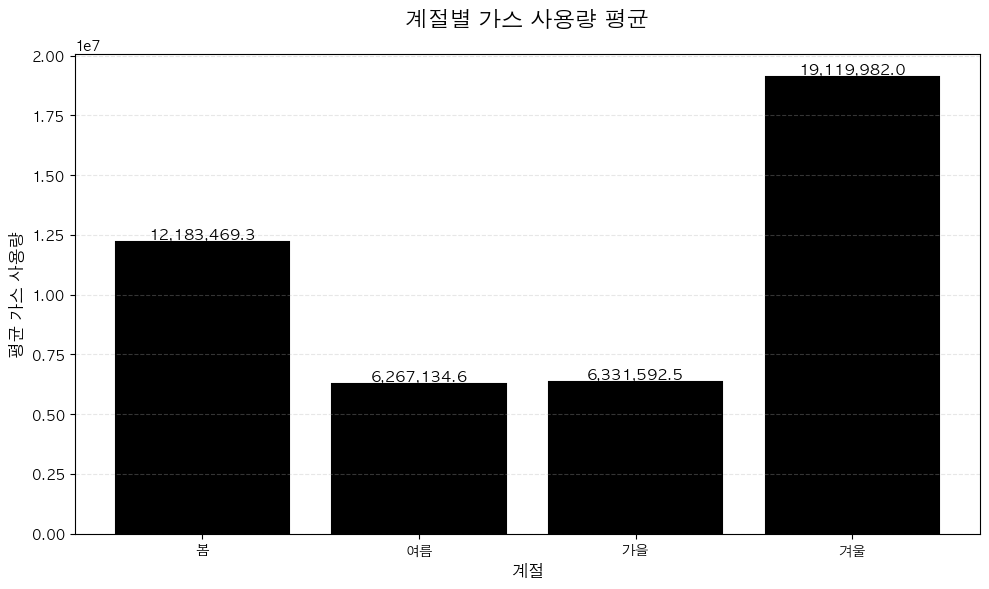

In [ ]:
import matplotlib.pyplot as plt

# 1. 한글 폰트 설정 (한글 깨짐 방지)
plt.rcParams['font.family'] = 'AppleGothic'  # Mac
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

# 2. 계절별 가스 사용량 평균 계산
df_season_gas = df_mapped.groupby('계절')['현년 가스사용량'].mean().reset_index()
df_season_gas.columns = ['계절', '평균 가스사용량']

# 계절 순서 정렬 (봄 → 여름 → 가을 → 겨울)
season_order = ['봄', '여름', '가을', '겨울']
df_season_gas['계절'] = pd.Categorical(df_season_gas['계절'], categories=season_order, ordered=True)
df_season_gas = df_season_gas.sort_values('계절')

# 3. 막대 그래프 그리기
plt.figure(figsize=(10, 6))
bars = plt.bar(df_season_gas['계절'], df_season_gas['평균 가스사용량'], 
               color = 'black', edgecolor='black', linewidth=1.5)

# 그래프 꾸미기
plt.title('계절별 가스 사용량 평균', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('계절', fontsize=12)
plt.ylabel('평균 가스 사용량', fontsize=12)
plt.grid(axis='y', alpha=0.3, linestyle='--')

# 각 막대 위에 구체적인 수치 표시
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:,.1f}',
             ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()

# 4. 그래프 출력
plt.show()


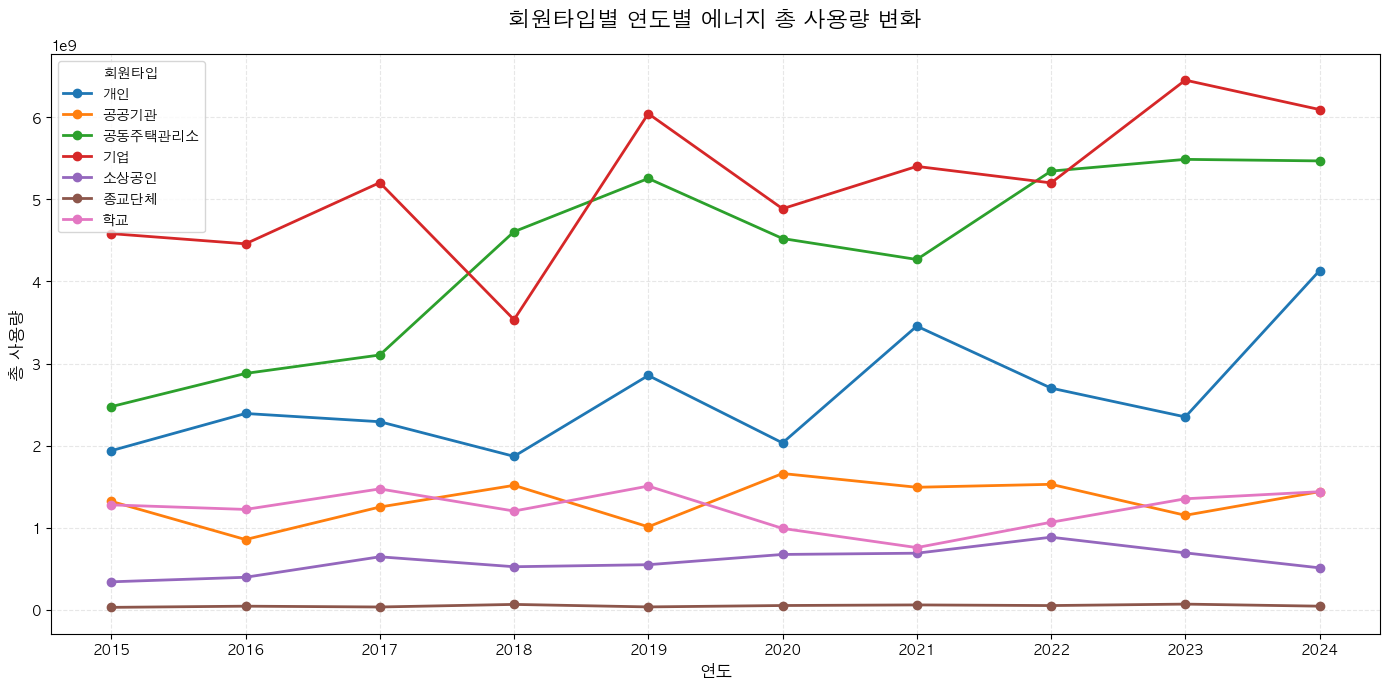

      년도     회원타입    현년 전기사용량     현년 가스사용량      현년 수도사용량   현년 지역난방 사용량  \
0   2015       개인  1544099007  215891522.0  1.086695e+08  6.858266e+07   
1   2015     공공기관  1268890357   41495896.0  9.774885e+06  0.000000e+00   
2   2015  공동주택관리소  2304043799   67798064.0  1.026493e+08  0.000000e+00   
3   2015       기업  4407187538  133842379.0  4.250023e+07  0.000000e+00   
4   2015     소상공인   310632682   19067467.0  9.260917e+06  0.000000e+00   
..   ...      ...         ...          ...           ...           ...   
65  2024  공동주택관리소  5231180820   57194396.0  1.814690e+08  0.000000e+00   
66  2024       기업  5856447031  196300694.0  4.321095e+07  0.000000e+00   
67  2024     소상공인   490378498   11428392.0  7.577351e+06  4.860450e+03   
68  2024     종교단체    40414661    1428454.0  2.870920e+05  0.000000e+00   
69  2024       학교  1388530657   31401267.0  1.735398e+07  1.614196e+05   

            총사용량  
0   1.937243e+09  
1   1.320161e+09  
2   2.474491e+09  
3   4.583530e+09  
4   3.389611e+08

In [ ]:
import matplotlib.pyplot as plt

# 한글 폰트 설정
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

# 회원타입별, 연도별 에너지 총 사용량 계산
df_energy_type = df_mapped.groupby(['년도', '회원타입']).agg({
    '현년 전기사용량': 'sum',
    '현년 가스사용량': 'sum', 
    '현년 수도사용량': 'sum',
    '현년 지역난방 사용량': 'sum'
}).reset_index()

# 총사용량 컬럼 추가
df_energy_type['총사용량'] = (df_energy_type['현년 전기사용량'] + 
                               df_energy_type['현년 가스사용량'] + 
                               df_energy_type['현년 수도사용량'] + 
                               df_energy_type['현년 지역난방 사용량'])

# 그래프 그리기
plt.figure(figsize=(14, 7))

# 각 회원타입별로 선 그리기
for member_type in df_energy_type['회원타입'].unique():
    data = df_energy_type[df_energy_type['회원타입'] == member_type]
    plt.plot(data['년도'], data['총사용량'], 
             marker='o', linewidth=2, markersize=6, label=member_type)

# 그래프 꾸미기
plt.title('회원타입별 연도별 에너지 총 사용량 변화', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('연도', fontsize=12)
plt.ylabel('총 사용량', fontsize=12)
plt.legend(title='회원타입', fontsize=10, loc='best')
plt.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('회원타입별_연도별_에너지_총사용량.png', dpi=300, bbox_inches='tight')
plt.show()

print(df_energy_type)

In [ ]:
# 연도별 에너지 총 사용량이 얼마나 증가하는가 선형회구 추세분석
import statsmodels.formula.api as smf
model = smf.ols(formula='총사용량 ~ 년도', data=df_energy).fit()
print(model.summary())

#년도가 “10가지 범주”인데
#각 범주마다 총사용량이 정확히 한 값만 존재하기 때문에 t의 값이 없음

                            OLS Regression Results                            
Dep. Variable:                   총사용량   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                    nan
Method:                 Least Squares   F-statistic:                       nan
Date:                Mon, 13 Oct 2025   Prob (F-statistic):                nan
Time:                        22:56:05   Log-Likelihood:                 99.936
No. Observations:                  10   AIC:                            -179.9
Df Residuals:                       0   BIC:                            -176.8
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   1.196e+10        inf          0        n

/opt/homebrew/lib/python3.13/site-packages/scipy/stats/_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=10 observations were given.
  return hypotest_fun_in(*args, **kwds)
/opt/homebrew/lib/python3.13/site-packages/statsmodels/regression/linear_model.py:1795: RuntimeWarning: divide by zero encountered in divide
  return 1 - (np.divide(self.nobs - self.k_constant, self.df_resid)
/opt/homebrew/lib/python3.13/site-packages/statsmodels/regression/linear_model.py:1795: RuntimeWarning: invalid value encountered in scalar multiply
  return 1 - (np.divide(self.nobs - self.k_constant, self.df_resid)
/opt/homebrew/lib/python3.13/site-packages/statsmodels/regression/linear_model.py:1717: RuntimeWarning: divide by zero encountered in scalar divide
  return np.dot(wresid, wresid) / self.df_resid


In [ ]:
#자동화된 EDA 도구 
from ydata_profiling import ProfileReport

profile = ProfileReport(df_energy, title='연도별 에너지사용 보고서')

profile

Render HTML: 100%|██████████| 1/1 [00:00<00:00,  2.04it/s]


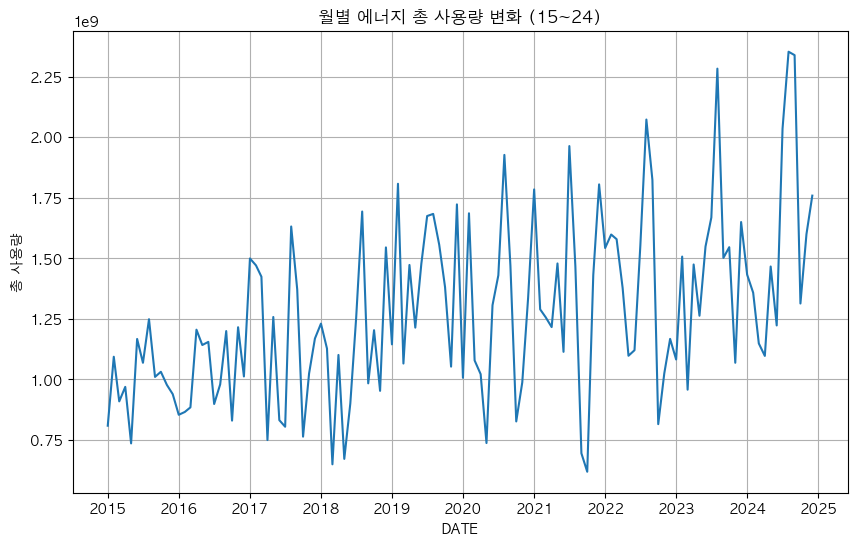

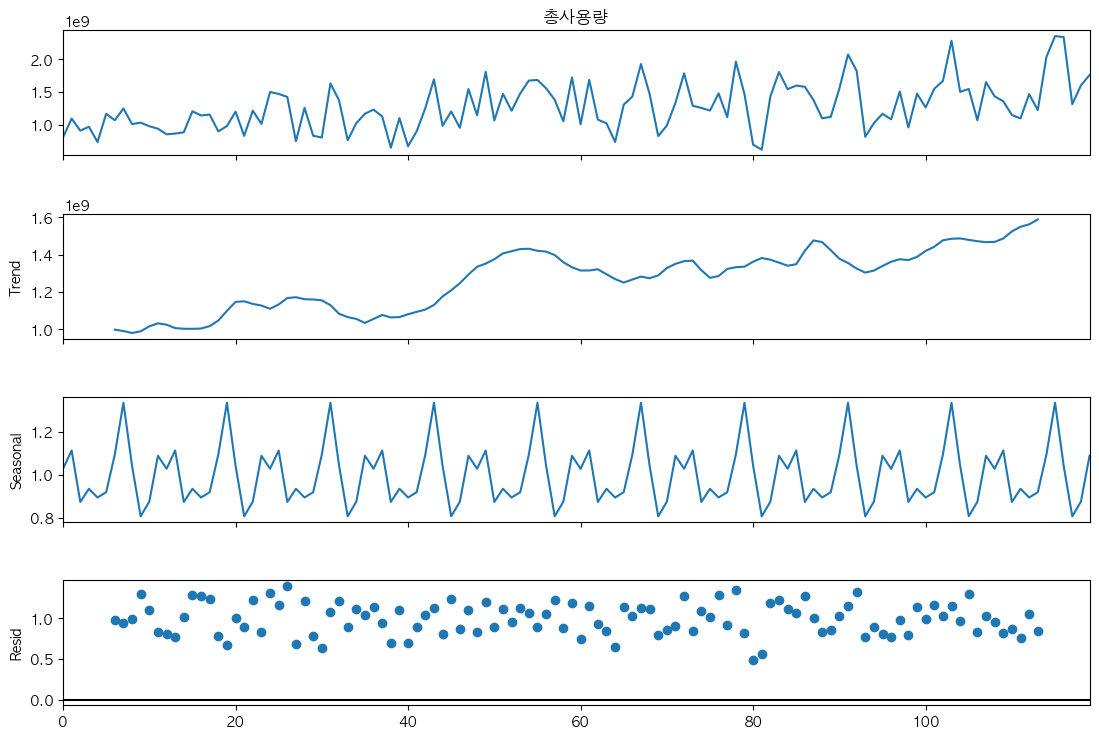

In [ ]:
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
# 1. 한글 폰트 설정 (한글 깨짐 방지)
plt.rcParams['font.family'] = 'AppleGothic'  # Mac
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

# 데이터를 숫자형으로 변환
df_mapped['현년 전기사용량'] = pd.to_numeric(df_mapped['현년 전기사용량'], errors='coerce')
df_mapped['현년 가스사용량'] = pd.to_numeric(df_mapped['현년 가스사용량'], errors='coerce')
df_mapped['현년 수도사용량'] = pd.to_numeric(df_mapped['현년 수도사용량'], errors='coerce')
df_mapped['현년 지역난방 사용량'] = pd.to_numeric(df_mapped['현년 지역난방 사용량'], errors='coerce')
df_mapped['Date'] = pd.to_datetime(df_mapped['년도'].astype(str)+'-'+df_mapped['월'].astype(str)+'-01')

# 2. 연도별 에너지 총 사용량 계산
df_energy = df_mapped.groupby('Date').agg({
    '현년 전기사용량': 'sum',
    '현년 가스사용량': 'sum', 
    '현년 수도사용량': 'sum',
    '현년 지역난방 사용량': 'sum'
}).reset_index()
df_energy.set_index('Date').sort_index()
df_energy

# 총 사용량 컬럼 추가
df_energy['총사용량'] = (df_energy['현년 전기사용량'] + 
                         df_energy['현년 가스사용량'] + 
                         df_energy['현년 수도사용량'] + 
                         df_energy['현년 지역난방 사용량'])
df_energy
# 3. 시계열 시각화
plt.figure(figsize=(10, 6))
plt.plot(df_energy['Date'], df_energy['총사용량'])
plt.title('월별 에너지 총 사용량 변화 (15~24)')
plt.xlabel('DATE')
plt.ylabel('총 사용량')
plt.grid(True)
plt.show()

decomposition = seasonal_decompose(df_energy['총사용량'], model='multiplicative', period=12)
fig = decomposition.plot()
fig.set_size_inches(12,8)
plt.tight_layout
plt.style.use('seaborn-v0_8-whitegrid')
plt.show()


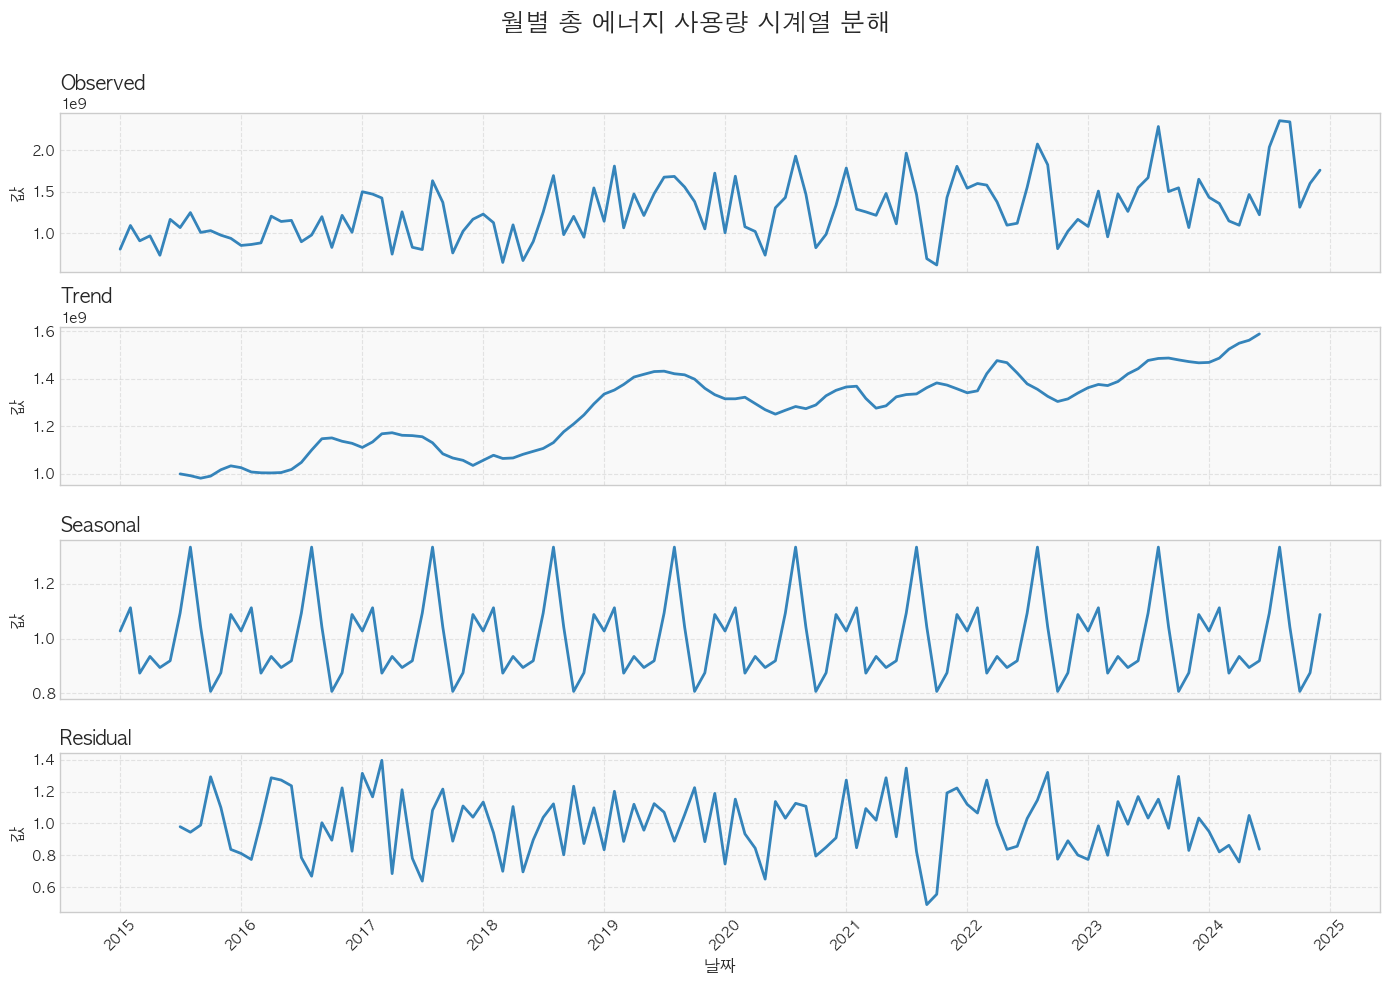

In [25]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

# 1. 한글 폰트 설정 (한글 깨짐 방지)
plt.rcParams['font.family'] = 'AppleGothic'  # Mac
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

df_energy = df_energy.set_index('Date').sort_index()
decomposition = seasonal_decompose(df_energy['총사용량'], model='multiplicative', period=12)

# 보기 좋은 그래프 설정
fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)

components = {
    'Observed': decomposition.observed,
    'Trend': decomposition.trend,
    'Seasonal': decomposition.seasonal,
    'Residual': decomposition.resid
}

for ax, (title, data) in zip(axes, components.items()):
    ax.plot(data, color='tab:blue', linewidth=2, alpha=0.9)
    ax.set_title(f'{title}', fontsize=14, fontweight='bold', loc='left')
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.set_ylabel('값', fontsize=12)
    ax.tick_params(axis='x', rotation=45)
    ax.set_facecolor('#f9f9f9')  # 밝은 회색 배경

plt.suptitle('월별 총 에너지 사용량 시계열 분해', fontsize=18, fontweight='bold')
plt.xlabel('날짜', fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

                            OLS Regression Results                            
Dep. Variable:                   총사용량   R-squared:                       0.848
Model:                            OLS   Adj. R-squared:                  0.829
Method:                 Least Squares   F-statistic:                     44.76
Date:                Tue, 14 Oct 2025   Prob (F-statistic):           0.000154
Time:                        16:04:59   Log-Likelihood:                -220.31
No. Observations:                  10   AIC:                             444.6
Df Residuals:                       8   BIC:                             445.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -1.472e+12   2.22e+11     -6.621      0.0

/opt/homebrew/lib/python3.13/site-packages/scipy/stats/_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=10 observations were given.
  return hypotest_fun_in(*args, **kwds)


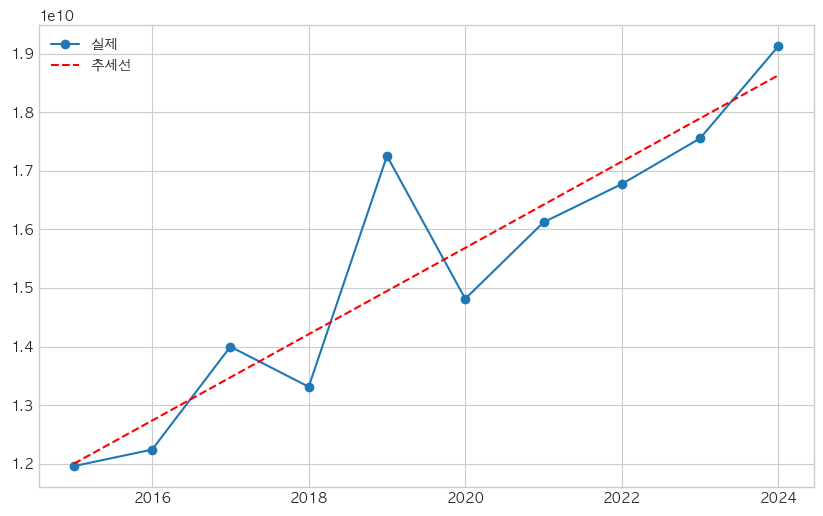

In [35]:
import statsmodels.api as sm
import matplotlib.pyplot as plt

# 1. 한글 폰트 설정 (한글 깨짐 방지)
plt.rcParams['font.family'] = 'AppleGothic'  # Mac
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

# 데이터를 숫자형으로 변환
df_mapped['현년 전기사용량'] = pd.to_numeric(df_mapped['현년 전기사용량'], errors='coerce')
df_mapped['현년 가스사용량'] = pd.to_numeric(df_mapped['현년 가스사용량'], errors='coerce')
df_mapped['현년 수도사용량'] = pd.to_numeric(df_mapped['현년 수도사용량'], errors='coerce')
df_mapped['현년 지역난방 사용량'] = pd.to_numeric(df_mapped['현년 지역난방 사용량'], errors='coerce')

# 2. 연도별 에너지 총 사용량 계산
df_energy = df_mapped.groupby('년도').agg({
    '현년 전기사용량': 'sum',
    '현년 가스사용량': 'sum', 
    '현년 수도사용량': 'sum',
    '현년 지역난방 사용량': 'sum'
}).reset_index()

# 총 사용량 컬럼 추가
df_energy['총사용량'] = (df_energy['현년 전기사용량'] + 
                         df_energy['현년 가스사용량'] + 
                         df_energy['현년 수도사용량'] + 
                         df_energy['현년 지역난방 사용량'])

# df_energy: 년도, 총사용량 (년도는 정수)
df_energy['년도'] = pd.to_numeric(df_energy['년도'], errors='coerce')
df_energy = df_energy.sort_values('년도')
X = sm.add_constant(df_energy['년도'])
y = df_energy['총사용량']


model = sm.OLS(y, X).fit()
print(model.summary())

# 시각화
plt.figure(figsize=(10,6))
plt.plot(df_energy['년도'], y, 'o-', label='실제')
plt.plot(df_energy['년도'], model.predict(X), 'r--', label='추세선')
plt.legend()
plt.show()